> # Perform Quantum Operations
---
- <b>Define Pauli Operators 
- Apply quantum operators
---

<b>REFERENCE : </b>

https://quantum.cloud.ibm.com/docs/en/guides/operators-overview

https://quantum.cloud.ibm.com/docs/en/guides/operator-class


In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


In [2]:
import numpy as np
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp, process_fidelity

from qiskit.visualization import array_to_latex
from qiskit.circuit.library import XGate,YGate,ZGate,IGate
from qiskit.circuit import QuantumCircuit

> **SparsePauliOP**

- represents a general quantum operator
- **linear combination of Pauli strings**
- most commonly used to represent quantum observables

In [3]:
#Single-qubit Pauli operators

X = SparsePauliOp(["X"])
Y = SparsePauliOp(["Y"])
Z = SparsePauliOp(["Z"])
I = SparsePauliOp(["I"])

print(X)
print(Y)
print(Z)

SparsePauliOp(['X'],
              coeffs=[1.+0.j])
SparsePauliOp(['Y'],
              coeffs=[1.+0.j])
SparsePauliOp(['Z'],
              coeffs=[1.+0.j])


In [4]:
#Two-qubit operators
H = SparsePauliOp(
    ["XX", "YY", "ZZ"],
    coeffs=[1.0, 1.0, 1.0]
)
print(H)

SparsePauliOp(['XX', 'YY', 'ZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])


 ![](pic1.png)

> Using from_sparse_list

flexible way to construct operators. It takes tuples of:

(Pauli string, qubit indices, coefficient)

In [5]:
H = SparsePauliOp.from_sparse_list(
    [
        ("ZX", [1, 4], 1.0),
        ("YY", [0, 3], 2.0),
    ],
    num_qubits=5
)

print(H)

SparsePauliOp(['XIIZI', 'IYIIY'],
              coeffs=[1.+0.j, 2.+0.j])


>Using from_list method 

Construct from a list of Pauli strings and coefficients.
### equals the following construction from "dense" Paulis

In [6]:

op = SparsePauliOp.from_list([("XIIZI", 1), ("IYIIY", 2)])
print(op)

SparsePauliOp(['XIIZI', 'IYIIY'],
              coeffs=[1.+0.j, 2.+0.j])


> Attributes: paulis, coeffs

In [7]:
op.paulis

PauliList(['XIIZI', 'IYIIY'])

In [8]:
op.coeffs

array([1.+0.j, 2.+0.j])

 ![](pic2.png)

> Example XY operator

In [9]:
# Example 1
op=SparsePauliOp(["X","Y"])
print(op)

SparsePauliOp(['X', 'Y'],
              coeffs=[1.+0.j, 1.+0.j])


In [10]:
array_to_latex(op)

<IPython.core.display.Latex object>

In [11]:
op.paulis

PauliList(['X', 'Y'])

In [12]:
op_Y=Pauli("Y")
array_to_latex(op_Y)

<IPython.core.display.Latex object>

In [13]:
op_X=Pauli("X")
array_to_latex(op_X)

<IPython.core.display.Latex object>

> understand the matrix of Example 1

In [14]:
array_to_latex(op_X.to_matrix() +  op_Y.to_matrix())

<IPython.core.display.Latex object>

In [15]:
# Example 2
op=SparsePauliOp(["XY"])
print(op)

SparsePauliOp(['XY'],
              coeffs=[1.+0.j])


In [16]:
# View the full 4x4 matrix
print(op.to_matrix())

[[0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j]
 [0.+0.j 0.-1.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]]


In [17]:
array_to_latex(op)

<IPython.core.display.Latex object>

In [18]:
op.paulis

PauliList(['XY'])

> Understand the matrix of Example 2

In [19]:
array_to_latex(op_X.to_matrix() * op_Y.to_matrix())

<IPython.core.display.Latex object>

In [20]:
array_to_latex(op_X.tensor(op_Y))

<IPython.core.display.Latex object>

**NOTE:**
SparsePauliOp-----
sparse representation of an N-qubit matrix Operator in terms of N-qubit PauliList and complex coefficients

### In Qiskit, qubit ordering is right-to-left (little-endian). 
The string XY means X acts on Qubit 1 and Y acts on Qubit 0.

 ![](pic3.png)

> Arithmetric Operations on SparsePauliOP

In [21]:
# Adding Operators
X = SparsePauliOp(["X"])
Y = SparsePauliOp(["Y"])

print(X+Y)


SparsePauliOp(['X', 'Y'],
              coeffs=[1.+0.j, 1.+0.j])


In [22]:
# Mulitply Operators
X = SparsePauliOp(["X"])
Y = SparsePauliOp(["Y"])

print(X @ Y)

SparsePauliOp(['Z'],
              coeffs=[0.+1.j])


> XY= iZ

In [23]:
# Mulitply Operator by a scalar
X = SparsePauliOp(["X"])
Y = SparsePauliOp(["Y"])

print(2 * X)

SparsePauliOp(['X'],
              coeffs=[2.+0.j])


In [24]:
# Tensor Product
X = SparsePauliOp(["X"])
Y = SparsePauliOp(["Y"])

print(X.tensor(Y))

SparsePauliOp(['XY'],
              coeffs=[1.+0.j])


In [25]:
array_to_latex(X.tensor(Y).to_matrix())

<IPython.core.display.Latex object>

In [26]:
array_to_latex(Y.tensor(X).to_matrix())

<IPython.core.display.Latex object>

> ### PAULI

The Pauli class represents a **single Pauli string** with an optional phase coefficient from the set 

{+1,i,−1,−i}. 

A Pauli can be initialized by passing a string of characters from the set {"I", "X", "Y", "Z"}, 

optionally prefixed by one of {"", "i", "-", "-i"} to represent the phase coefficient.

In [27]:
op=Pauli("X")
print(op)

X


In [28]:
array_to_latex(op)

<IPython.core.display.Latex object>

In [29]:
op=Pauli("Y")
array_to_latex(op)

<IPython.core.display.Latex object>

In [30]:
op=Pauli("Z")
array_to_latex(op)

<IPython.core.display.Latex object>

In [31]:
op=Pauli("I")
array_to_latex(op)

<IPython.core.display.Latex object>

> 

In [32]:
# Another example
op=Pauli("XY")
array_to_latex(op)

<IPython.core.display.Latex object>

In [33]:
op=Pauli("XX")
array_to_latex(op)

<IPython.core.display.Latex object>

> Attributes: dim, phase, to_matrix

In [34]:
print(f"Dimension of {op}: {op.dim}")
print(f"Phase of {op}: {op.phase}")
print(f"Matrix representation of {op}: \n {op.to_matrix()}")

Dimension of XX: (4, 4)
Phase of XX: 0
Matrix representation of XX: 
 [[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]]


> Phase: Phase of the operator (0, 1, 2, 3 representing +1, i, -1, -i)

In [35]:
op=Pauli("-1XX")
print(f"Phase of {op}: {op.phase}")

op=Pauli("-iXX")
print(f"Phase of {op}: {op.phase}")

op=Pauli("iXX")
print(f"Phase of {op}: {op.phase}")

Phase of -XX: 2
Phase of -iXX: 1
Phase of iXX: 3


** NOTE:*** In the string representation qubit-0 corresponds to the right-most Pauli character, and qubit-(n−1) to the left-most Pauli character.

> ### Operator Class

 -- Represents a general linear operator
 
 -- Unlike SparsePauliOp, Operator stores the linear operator as a dense matrix. 
 
 **LIMITATION:** the Operator class is only suitable for use with a small number of qubits.

 **Operator Initialization Methods**
 1. Pauli objects
 2. Gate and Instruction objects
 3. QuantumCircuit objects

 **NOTE:**
 1. we can use the Operator class as a unitary simulator to compute the final unitary matrix for a quantum circuit, without having to call a simulator backend

 2. **Unsupported operations are:** measure, reset, conditional operations,

In [36]:
# Create an Operator from a Pauli object
pauliX=Pauli("X")
Operator(pauliX)

Operator([[0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


In [37]:
pauliX

Pauli('X')

In [38]:
array_to_latex(Operator(pauliX))

<IPython.core.display.Latex object>

In [39]:
# Create an Operator from a Gate object
Operator(XGate())

Operator([[0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


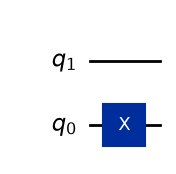

In [40]:
# Create an operator from a QuantumCircuit object
qc=QuantumCircuit(2)
qc.x(0)

qc.draw(output="mpl",reverse_bits=True)

In [41]:
Operator(qc)

Operator([[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [42]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

In [43]:
q0 = SparsePauliOp(["X"])
q1 = SparsePauliOp(["I"])

print(q1.tensor(q0))

array_to_latex(q1.tensor(q0))

SparsePauliOp(['IX'],
              coeffs=[1.+0.j])


<IPython.core.display.Latex object>

> Use Operators in circuits

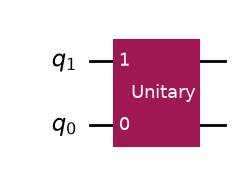

In [44]:
# Create a IX operator 
IX = Operator(Pauli("IX"))

# Using append method
qc=QuantumCircuit(2)
qc.append(IX,[0,1])
qc.draw(output="mpl",reverse_bits=True)


In [45]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

**NOTE:**

Unitary Operators can be directly inserted into a QuantumCircuit 

How ??? using  QuantumCircuit.append method

This converts the Operator into a UnitaryGate object, which is added to the circuit.

In [46]:
Operator(qc).is_unitary()

True

> **How to check whether an Operator is unitary or not ?**

 Operator.is_unitary() function

    - returns True if the operator is unitary 
    - False otherwise.

> Tensor product

the **tensor product a⊗b**, 

-- a is the current Operator, and 

-- b is the other Operator.

In [47]:
op1 = Operator(Pauli("X"))
op2 = Operator(Pauli("Y"))
array_to_latex(op1.tensor(op2))


# op1 tensor op1
#subsystems indexed as 
# matrix op2 on subsystem 0, and 
# matrix op1 on subsystem 1.

<IPython.core.display.Latex object>

> Tensor expand

Return the reverse-order tensor product with another Operator.

In [48]:
array_to_latex(op1.expand(op2))


# op2 tensor op1 
#subsystems indexed as 
# matrix op1 on subsystem 1, and 
# matrix op2  on subsystem 0.

<IPython.core.display.Latex object>

> Compose means implement matrix multiplication in the Operators

In [49]:
array_to_latex(op2.compose(op1))

<IPython.core.display.Latex object>

In [50]:
# Mulitply Operators
X = SparsePauliOp(["X"])
Y = SparsePauliOp(["Y"])

array_to_latex(X @ Y)

<IPython.core.display.Latex object>

**NOTE:**

 -- tensor, expand, and compose preserves the unitarity of unitary operators, 
 
 -- linear combinations do not; hence, adding two unitary operators will, in general, result in a non-unitary operator:

In [51]:
op= 3*X+Y
array_to_latex(op)

<IPython.core.display.Latex object>

In [52]:
op.is_unitary()

np.False_

> **Compare Operators**

In [53]:
Operator(X @ X) == Operator(IGate())

True

In [54]:
Operator(Pauli("X")) == Operator(YGate())

False

In [55]:
Operator(Pauli("X")) == Operator(XGate())

True

In [56]:
Operator(Pauli("X")) == np.exp(1j)*Operator(XGate())

False

**NOTE:**

    -- each matrix element of the operators is approximately equal <br>
    -- two unitaries that differ by a global phase are not considered equal:

> **Process Fidelity**

-- information-theoretic quantity for how close two quantum channels are to each other

**NOTE:** in the case of unitary operators it does not depend on global phase.

"process fidelity is generally only a valid measure of closeness if the input operators are unitary (or CP in the case of quantum channels) "

In [57]:
F = process_fidelity(op1, op2)
print("Process fidelity =", F)

Process fidelity = 0.0


In [58]:
F = process_fidelity(op1, op1)
print("Process fidelity =", F)

Process fidelity = 1.0


In [59]:
op3=np.exp(1j)*Operator(XGate())
F = process_fidelity(op1, op3)
print("Process fidelity =", F)

Process fidelity = 1.0


> additional NOTES

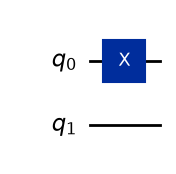

In [60]:
qc=QuantumCircuit(2)
qc.x(0)
qc.draw(output="mpl")

In [61]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

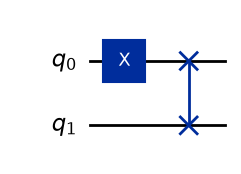

In [62]:
# Swap
qc=QuantumCircuit(2)
qc.x(0)
qc.swap(0,1)

qc.draw(output="mpl")

In [63]:

array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

In [64]:
q0 = SparsePauliOp(["X"])
q1 = SparsePauliOp(["I"])

print(q1.tensor(q0))

array_to_latex(q1.tensor(q0))

SparsePauliOp(['IX'],
              coeffs=[1.+0.j])


<IPython.core.display.Latex object>

In [65]:
q0 = SparsePauliOp(["X"])
q1 = SparsePauliOp(["I"])

print(q0.tensor(q1))

array_to_latex(q0.tensor(q1))

SparsePauliOp(['XI'],
              coeffs=[1.+0.j])


<IPython.core.display.Latex object>

> from_label()



In [66]:
#Creates an operator from labels such as "X", "Y", "Z"

X = Operator.from_label("X")
array_to_latex(X)


<IPython.core.display.Latex object>

In [67]:
print(X.to_matrix())

[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


In [68]:
XX = Operator.from_label("XX")
array_to_latex(XX)

<IPython.core.display.Latex object>

> to_instruction()

Converts the operator into a circuit instruction

In [69]:
X = Operator.from_label("X")

inst=X.to_instruction()

print(inst)

Instruction(name='unitary', num_qubits=1, num_clbits=0, params=[array([[0.+0.j, 1.+0.j],
       [1.+0.j, 0.+0.j]])])


In [70]:
array_to_latex(inst)

<IPython.core.display.Latex object>

In [71]:
qc=QuantumCircuit(1)
qc.append(inst,[0])

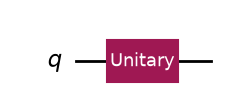

In [72]:
qc.draw(output="mpl")

In [73]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

> **NOTE:**

to_instruction() converts a Qiskit Operator into a circuit instruction that you can append to a QuantumCircuit.

> ### ScalarOp : qiskit.quantum_info.ScalarOp(dims=None, coeff=1)

"symbolic representation of a scalar identity operator on multiple subsystems"

REFERENCE : https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.ScalarOp


In [74]:
from qiskit.quantum_info import ScalarOp

op = ScalarOp(2, coeff=3)

print(op)
print("Coefficient:", op.coeff)
print("Number of qubits:", op.num_qubits)
array_to_latex(op.to_matrix())

# A subsystem of dimension 2 is one qubit.
#dims argument is subsystem dimensions

ScalarOp((2,), coeff=3)
Coefficient: 3
Number of qubits: 1


<IPython.core.display.Latex object>

In [75]:
op = ScalarOp([2,2], coeff=3)

print(op)
print("Coefficient:", op.coeff)
print("Number of qubits:", op.num_qubits)
array_to_latex(op.to_matrix())

ScalarOp((2, 2), coeff=3)
Coefficient: 3
Number of qubits: 2


<IPython.core.display.Latex object>

``ScalarOp(2, coeff=3)  ``     # one 2-dimensional subsystem = 1 qubit

``ScalarOp((2, 2), coeff=3)``  # two 2-dimensional subsystems = 2 qubits